In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the data (Replace with your actual file path)
df = pd.read_csv('accident.csv')

In [4]:
# Step 2: Check the data structure and handle missing data
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Accident_ID         300 non-null    object 
 1   State               300 non-null    object 
 2   Date                300 non-null    object 
 3   Time                300 non-null    object 
 4   Reason              300 non-null    object 
 5   Number_of_Deaths    300 non-null    int64  
 6   Number_of_Injuries  300 non-null    object 
 7   Road_Type           300 non-null    object 
 8   Weather_Conditions  300 non-null    object 
 9   Alcohol_Involved    300 non-null    object 
 10  Driver_Fatigue      300 non-null    object 
 11  Road_Conditions     300 non-null    object 
 12  Speed_Limit         299 non-null    float64
dtypes: float64(1), int64(1), object(11)
memory usage: 30.6+ KB
None
  Accident_ID           State        Date      Time                Reason  \
0        1001 

In [7]:
if 'Weather' in df.columns:
    le = LabelEncoder()
    df['Weather'] = le.fit_transform(df['Weather'])
else:
    print("Column 'Weather' not found!")

# Encoding 'Road_Conditions' column if it exists in the dataset
if 'Road_Condition' in df.columns:
    df['Road_Condition'] = le.fit_transform(df['Road_Condition'])
else:
    print("Column 'Road_Condition' not found!")

# Encoding 'Time_of_Day' column if it exists in the dataset
if 'Time_of_Day' in df.columns:
    df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
else:
    print("Column 'Time_of_Day' not found!")

Column 'Weather' not found!
Column 'Road_Condition' not found!
Column 'Time_of_Day' not found!


In [9]:
if 'Weather' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Weather', data=df, palette='Set2')
    plt.title('Accident Distribution by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()

if 'Road_Condition' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Road_Condition', data=df, palette='Set3')
    plt.title('Accident Distribution by Road Condition')
    plt.xlabel('Road Condition')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()

# Time of Day distribution
if 'Time_of_Day' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Time_of_Day', data=df, palette='pastel')
    plt.title('Accident Distribution by Time of Day')
    plt.xlabel('Time of Day')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()



In [10]:
# Step 7: Visualize accident severity based on contributing factors like weather, road conditions, and time of day
if 'Weather' in df.columns and 'Accident_Severity' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Weather', hue='Accident_Severity', data=df, palette='coolwarm')
    plt.title('Accident Severity Distribution by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()

if 'Road_Condition' in df.columns and 'Accident_Severity' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Road_Condition', hue='Accident_Severity', data=df, palette='coolwarm')
    plt.title('Accident Severity Distribution by Road Condition')
    plt.xlabel('Road Condition')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()

if 'Time_of_Day' in df.columns and 'Accident_Severity' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Time_of_Day', hue='Accident_Severity', data=df, palette='coolwarm')
    plt.title('Accident Severity Distribution by Time of Day')
    plt.xlabel('Time of Day')
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=45)
    plt.show()



<ipython-input-11-200f4be04130>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='viridis')


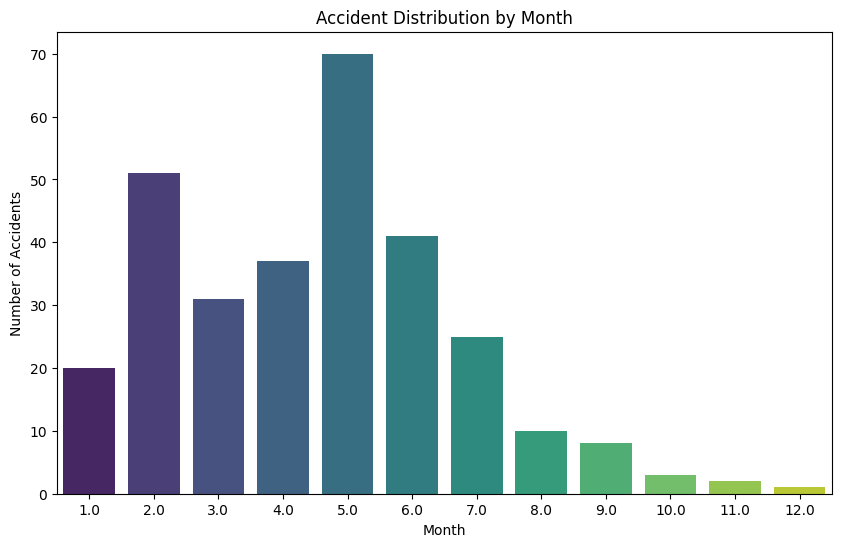

<ipython-input-11-200f4be04130>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=df, palette='plasma')


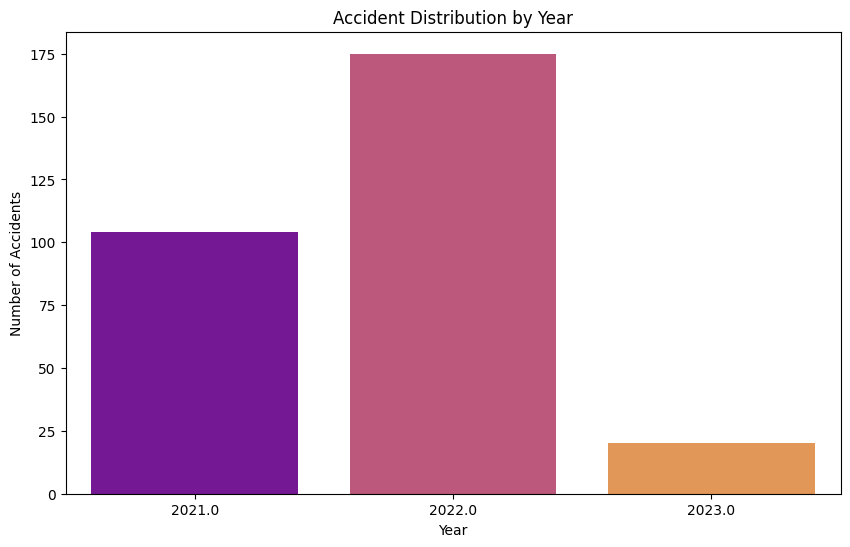

In [11]:
# Step 8: Analyze accident patterns over time (e.g., by day, month, year)
if 'Date' in df.columns:
    # Convert to datetime if necessary
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year

    plt.figure(figsize=(10, 6))
    sns.countplot(x='Month', data=df, palette='viridis')
    plt.title('Accident Distribution by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Accidents')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.countplot(x='Year', data=df, palette='plasma')
    plt.title('Accident Distribution by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Accidents')
    plt.show()
else:
    print("Date column not found!")